## Imports and setup

Import libraries for SVM (LinearSVC), cross-validation (GridSearchCV, StratifiedKFold), metrics (accuracy, precision, recall, F1, ROC-AUC, PR-AUC, confusion matrix, classification report), and plotting. Set a fixed random state and create the outputs directory.

In [ ]:
import os, time, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, confusion_matrix,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    classification_report
)
import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
os.makedirs("outputs", exist_ok=True)

## Load train/test data

Read the preprocessed feature matrices and labels from outputs/ (X_train, X_test, y_train, y_test) produced by data_processing ipynb, and print their shapes.

In [ ]:
# Load training data
X_train = pd.read_csv("outputs/X_train.csv")
X_test  = pd.read_csv("outputs/X_test.csv")
y_train = pd.read_csv("outputs/y_train.csv").squeeze().astype(int)
y_test  = pd.read_csv("outputs/y_test.csv").squeeze().astype(int)

print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("y_train:", y_train.shape, "y_test:", y_test.shape)

X_train: (360140, 13) X_test: (90036, 13)
y_train: (360140,) y_test: (90036,)


## Define model and hyperparameter grid

Create a base LinearSVC with class_weight="balanced". Define a search grid over C, loss (hinge, squared_hinge), tol, and max_iter, and set up 3-fold StratifiedKFold for cross-validation.

In [ ]:
# Define base Linear SVM and hyperparameter grid
base_svm = LinearSVC(class_weight="balanced", random_state=RANDOM_STATE)

param_grid = {
    "C":   [0.01, 0.1, 1, 10],  # Regularization parameter
    "loss": ["hinge", "squared_hinge"],  # Loss function
    "tol": [1e-3, 1e-4],  # Tolerance for stopping criteria
    "max_iter": [5000]   # increase if convergence warnings appear
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

## Grid search and model selection

Run GridSearchCV with macro F1 scoring to find the best LinearSVC hyperparameters. Fit on the training set, then print the best parameters, best CV score, and total search time. The refitted best estimator is stored as best_svm.

In [ ]:
# Grid search with cross-validation 
t0 = time.time()
grid = GridSearchCV(
    estimator=base_svm,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True
)
grid.fit(X_train, y_train)
train_time = time.time() - t0

best_svm = grid.best_estimator_
print("\nBest params:", grid.best_params_)
print(f"CV best macro-F1: {grid.best_score_:.4f}")
print(f"Grid search time: {train_time:.2f}s")

Fitting 3 folds for each of 16 candidates, totalling 48 fits


/Users/fernandourrea/Documents/SDSU/SDSU Fall 2025/CS 549 MAchine Learning/CS 549 Code/CS549venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/fernandourrea/Documents/SDSU/SDSU Fall 2025/CS 549 MAchine Learning/CS 549 Code/CS549venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/fernandourrea/Documents/SDSU/SDSU Fall 2025/CS 549 MAchine Learning/CS 549 Code/CS549venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/fernandourrea/Documents/SDSU/SDSU Fall 2025/CS 549 MAchine Learning/CS 549 Code/CS549venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iteration


Best params: {'C': 10, 'loss': 'hinge', 'max_iter': 5000, 'tol': 0.001}
CV best macro-F1: 0.9846
Grid search time: 270.76s


/Users/fernandourrea/Documents/SDSU/SDSU Fall 2025/CS 549 MAchine Learning/CS 549 Code/CS549venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


## Evaluate on test set

Use the best model’s decision_function to get scores and derive binary predictions (threshold 0). Compute accuracy, precision, recall, F1, macro F1, ROC-AUC, and PR-AUC; print the classification report and confusion matrix.

In [ ]:
# Evaluate best model on test set
scores = best_svm.decision_function(X_test)      
y_pred = (scores >= 0).astype(int)               

acc = accuracy_score(y_test, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="binary")
macro_f1 = precision_recall_fscore_support(y_test, y_pred, average="macro")[2]
roc_auc = roc_auc_score(y_test, scores)
pr_auc  = average_precision_score(y_test, scores)
cm = confusion_matrix(y_test, y_pred)

print("\nEvaluation report:")
print(classification_report(y_test, y_pred, target_names=["Benign","Malicious"]))
print(f"Accuracy: {acc:.3f} | Precision: {prec:.3f} | Recall: {rec:.3f} "
      f"| F1: {f1:.3f} | Macro-F1: {macro_f1:.3f}")
print(f"ROC-AUC: {roc_auc:.3f} | PR-AUC: {pr_auc:.3f}")
print("Confusion matrix:\n", cm)


Classification report:
              precision    recall  f1-score   support

      Benign       0.99      1.00      0.99     69148
   Malicious       1.00      0.96      0.98     20888

    accuracy                           0.99     90036
   macro avg       0.99      0.98      0.99     90036
weighted avg       0.99      0.99      0.99     90036

Accuracy: 0.989 | Precision: 0.997 | Recall: 0.958 | F1: 0.977 | Macro-F1: 0.985
ROC-AUC: 0.986 | PR-AUC: 0.981
Confusion matrix:
 [[69080    68]
 [  878 20010]]


## Plot ROC, Precision–Recall, and confusion matrix

Plot the ROC curve (with AUC), the Precision–Recall curve (with average precision), and a heatmap of the confusion matrix with class labels (Benign/Malicious).

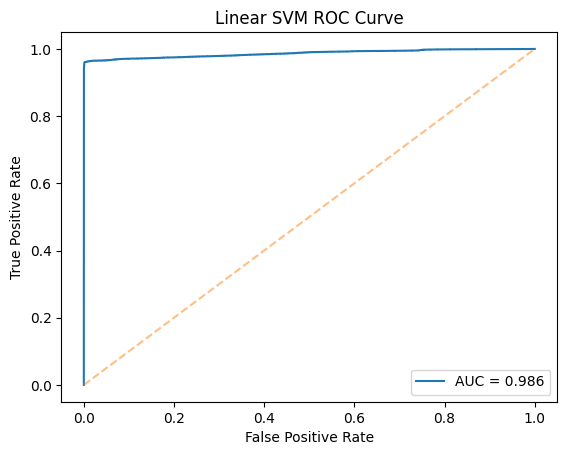

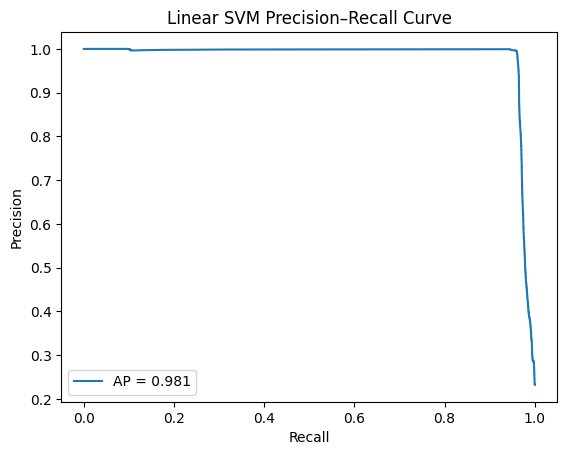

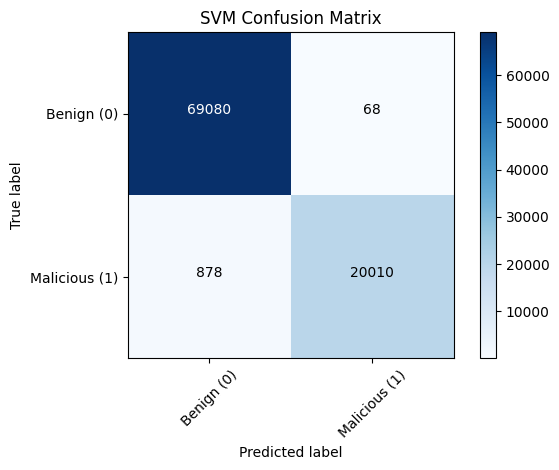

In [ ]:
# ROC curve
fpr, tpr, _ = roc_curve(y_test, scores)
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], "--", alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Linear SVM ROC Curve")
plt.legend()
plt.show()

# Precision–Recall curve
prec_curve, rec_curve, _ = precision_recall_curve(y_test, scores)
plt.figure()
plt.plot(rec_curve, prec_curve, label=f"AP = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Linear SVM Precision–Recall Curve")
plt.legend()
plt.show()

# Confusion matrix heatmap
plt.figure()
plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title("SVM Confusion Matrix")
plt.colorbar()
classes = ["Benign (0)", "Malicious (1)"]
ticks = np.arange(2)
plt.xticks(ticks, classes, rotation=45)
plt.yticks(ticks, classes)
thresh = cm.max() / 2.0
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, format(cm[i, j], "d"),
             ha="center",
             color="white" if cm[i, j] > thresh else "black")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()
